<a href="https://colab.research.google.com/github/jagadeesh-usd/composer-classification/blob/jag-dev/notebooks/02_Model_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Purpose: Load preprocessed data, train models, and evaluate performance.


In [9]:
# 1. Imports
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
                                     Flatten, Input, Concatenate, BatchNormalization,
                                     Embedding, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
# 2. Configuration
SAVE_DIR = "/content/drive/My Drive/composer_project/processed_data"
BATCH_SIZE = 128
EPOCHS = 25

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [11]:
# 3. Load Preprocessed Data
print("Loading pre-split data...")
SAVE_DIR = "/content/drive/My Drive/composer_project/processed_data_split"

with open(os.path.join(SAVE_DIR, 'train_sequences.pkl'), 'rb') as f:
    train_sequences = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'train_labels.pkl'), 'rb') as f:
    train_labels = pickle.load(f)

with open(os.path.join(SAVE_DIR, 'test_sequences.pkl'), 'rb') as f:
    test_sequences = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'test_labels.pkl'), 'rb') as f:
    test_labels = pickle.load(f)

with open(os.path.join(SAVE_DIR, 'preprocessing_data.pkl'), 'rb') as f:
    preprocessing_data = pickle.load(f)

note_to_int = preprocessing_data['note_to_int']
composers = preprocessing_data['composers']
vocab_size = preprocessing_data['vocab_size']

Loading pre-split data...


In [12]:
# 4. Prepare Data for Training
print("Preparing data for training...")

def sequences_to_numpy(sequences, labels, label_encoder):
    """Converts sequences and labels to numerical numpy arrays."""
    X = np.array([[note_to_int.get(note, note_to_int['UNK']) for note in seq] for seq in sequences])
    y_integers = label_encoder.transform(labels)
    y = to_categorical(y_integers, num_classes=len(label_encoder.classes_))
    return X, y

# Fit the label encoder on ALL possible composers to ensure consistency
label_encoder = LabelEncoder()
label_encoder.fit(composers)

# Convert the pre-split test data
X_test, y_test = sequences_to_numpy(test_sequences, test_labels, label_encoder)

# Convert the training data and then split it into training and validation sets
X_train_full, y_train_full = sequences_to_numpy(train_sequences, train_labels, label_encoder)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, # Create a 20% validation set from the training data
    random_state=42,
    stratify=y_train_full
)

print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Preparing data for training...
Training set: (168080, 100), Validation set: (42021, 100), Test set: (49105, 100)


In [13]:
# 5. Model Definitions

def create_lstm_model(input_shape, num_classes, vocab_size):
    """Creates a pure LSTM model."""
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=input_shape[1]),
        LSTM(256, return_sequences=True, dropout=0.3),
        LSTM(256, dropout=0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_cnn_model(input_shape, num_classes, vocab_size):
    """Creates a pure 1D CNN model."""
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=input_shape[1]),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(256, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_hybrid_model(input_shape, num_classes, vocab_size):
    """Creates a hybrid CNN-LSTM model."""
    input_layer = Input(shape=(input_shape[1],))
    embedding = Embedding(input_dim=vocab_size, output_dim=128)(input_layer)

    # CNN branch
    cnn_branch = Conv1D(128, 5, activation='relu')(embedding)
    cnn_branch = MaxPooling1D(2)(cnn_branch)
    cnn_branch = Dropout(0.3)(cnn_branch)
    cnn_branch = Flatten()(cnn_branch)

    # LSTM branch
    lstm_branch = LSTM(256, dropout=0.3)(embedding)

    # Combine
    combined = Concatenate()([lstm_branch, cnn_branch])
    combined = Dense(256, activation='relu')(combined)
    combined = BatchNormalization()(combined)
    combined = Dropout(0.5)(combined)
    output = Dense(num_classes, activation='softmax')(combined)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [14]:
# 6. Train and Evaluate Models
models_to_train = {
    'LSTM': create_lstm_model,
    'CNN': create_cnn_model,
    'Hybrid': create_hybrid_model,
}
models_info = {}
results = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
]

for name, model_func in models_to_train.items():
    print(f"\n--- Training {name} Model ---")
    model = model_func(X_train.shape, y_train.shape[1], vocab_size)
    model.summary()

    checkpoint = ModelCheckpoint(f'{SAVE_DIR}/best_{name}_model.h5', save_best_only=True, monitor='val_accuracy')

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks + [checkpoint],
        verbose=1
    )
    models_info[name] = {'model': model, 'history': history}

    print(f"\n--- Evaluating {name} Model ---")
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    results[name] = {
        'accuracy': accuracy_score(y_test_classes, y_pred_classes),
        'report': classification_report(y_test_classes, y_pred_classes, target_names=composers),
        'cm': confusion_matrix(y_test_classes, y_pred_classes)
    }
    print(results[name]['report'])


--- Training LSTM Model ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8697 - loss: 0.3454 - val_accuracy: 0.9986 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 2/25
1312/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9932 - loss: 0.0217

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9933 - loss: 0.0216 - val_accuracy: 0.9997 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9994 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 4/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9971 - loss: 0.0088 - val_accuracy: 0.9994 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 5/25
1311/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9978 - loss: 0.0065

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9978 - loss: 0.0065 - val_accuracy: 0.9998 - val_loss: 7.1552e-04 - learning_rate: 0.0010
Epoch 6/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9990 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 7/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9936 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 8/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9997 - val_loss: 7.8524e-04 - learning_rate: 0.0010
Epoch 9/25
1312/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.0054

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.9999 - val_loss: 3.3608e-04 - learning_rate: 0.0010
Epoch 10/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9991 - loss: 0.0030 - val_accuracy: 0.9999 - val_loss: 3.6270e-04 - learning_rate: 0.0010
Epoch 11/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 0.9998 - val_loss: 4.8554e-04 - learning_rate: 0.0010
Epoch 12/25
1310/1314 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9991 - loss: 0.0029

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 8.5115e-05 - learning_rate: 0.0010
Epoch 13/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9992 - loss: 0.0024 - val_accuracy: 0.9998 - val_loss: 4.9819e-04 - learning_rate: 0.0010
Epoch 14/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 0.9999 - val_loss: 4.7218e-04 - learning_rate: 0.0010
Epoch 15/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9999 - val_loss: 2.9610e-04 - learning_rate: 0.0010
Epoch 16/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9998 - val_loss: 7.7311e-04 - learning_rate: 0.0010
Epoch 17/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9999 - val_loss: 2.1888e-04 - learning_rate: 0.0010
Epoch 18/25
1314/1314 ━━━━━━━━━━━━━━━━━━━━ 15s

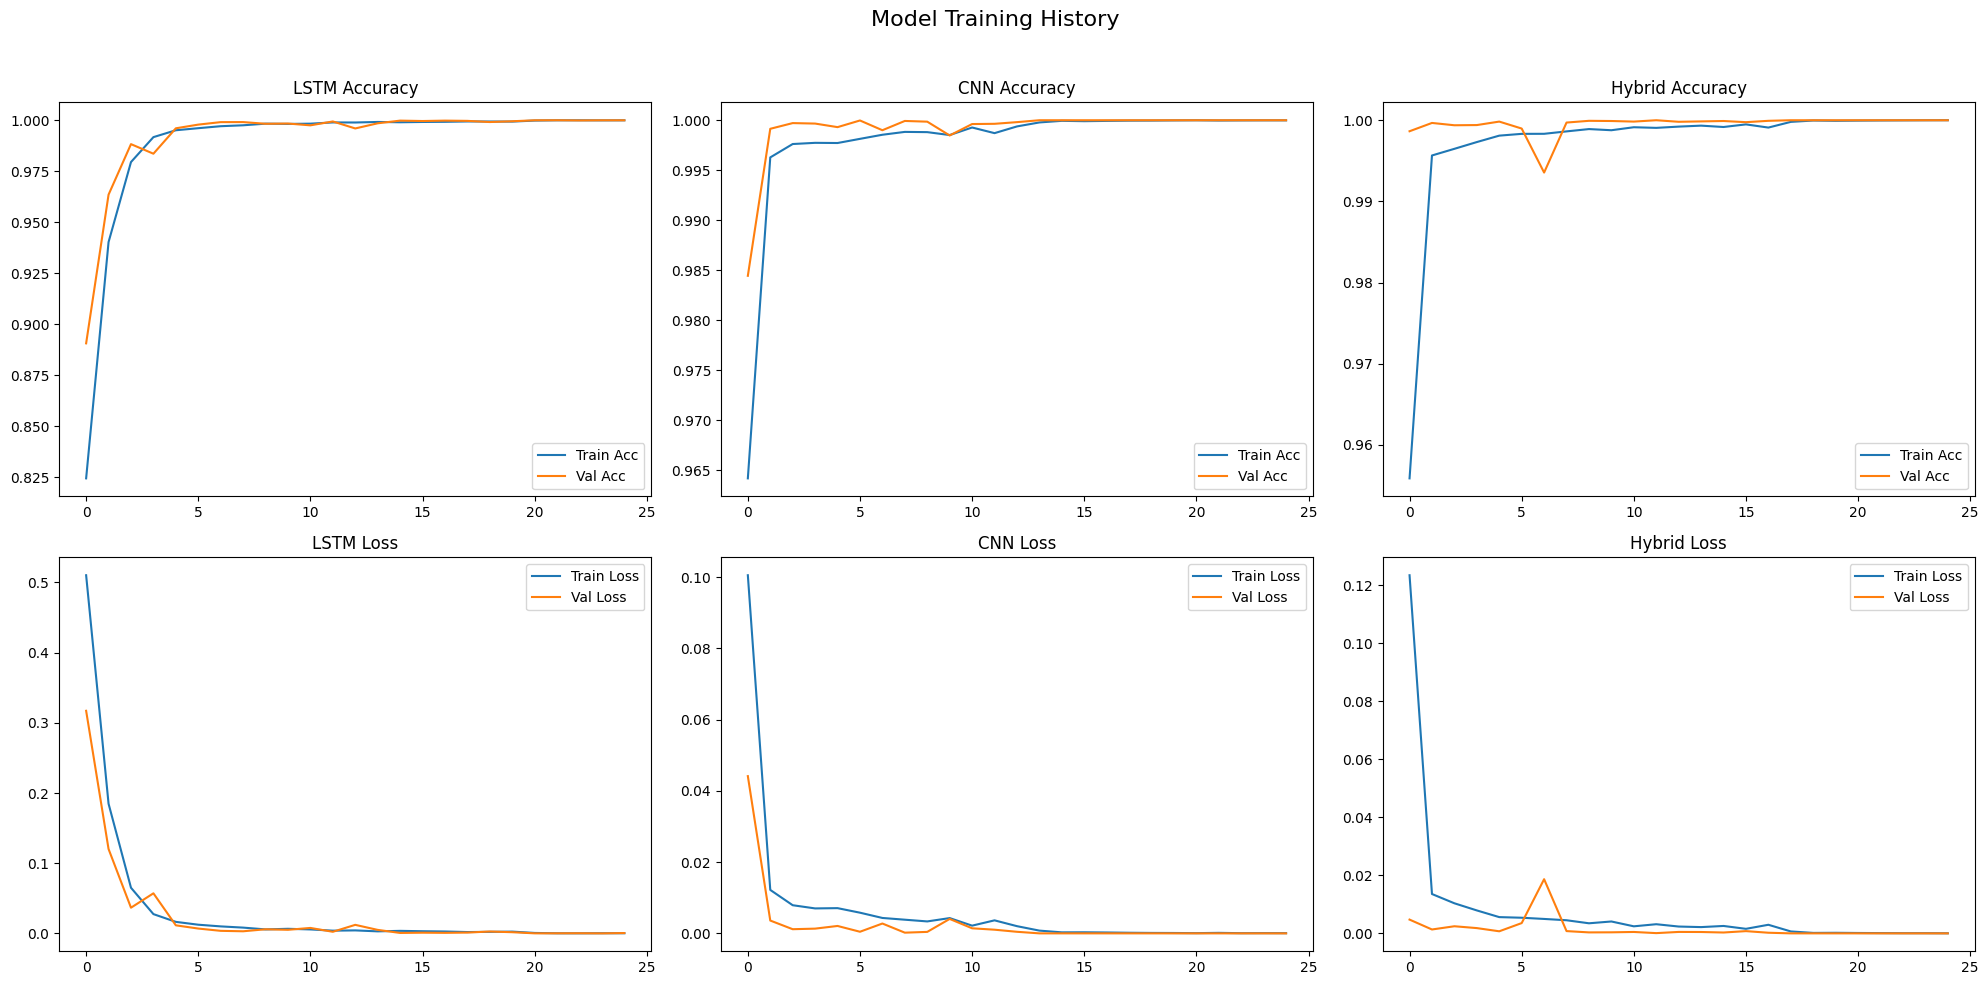

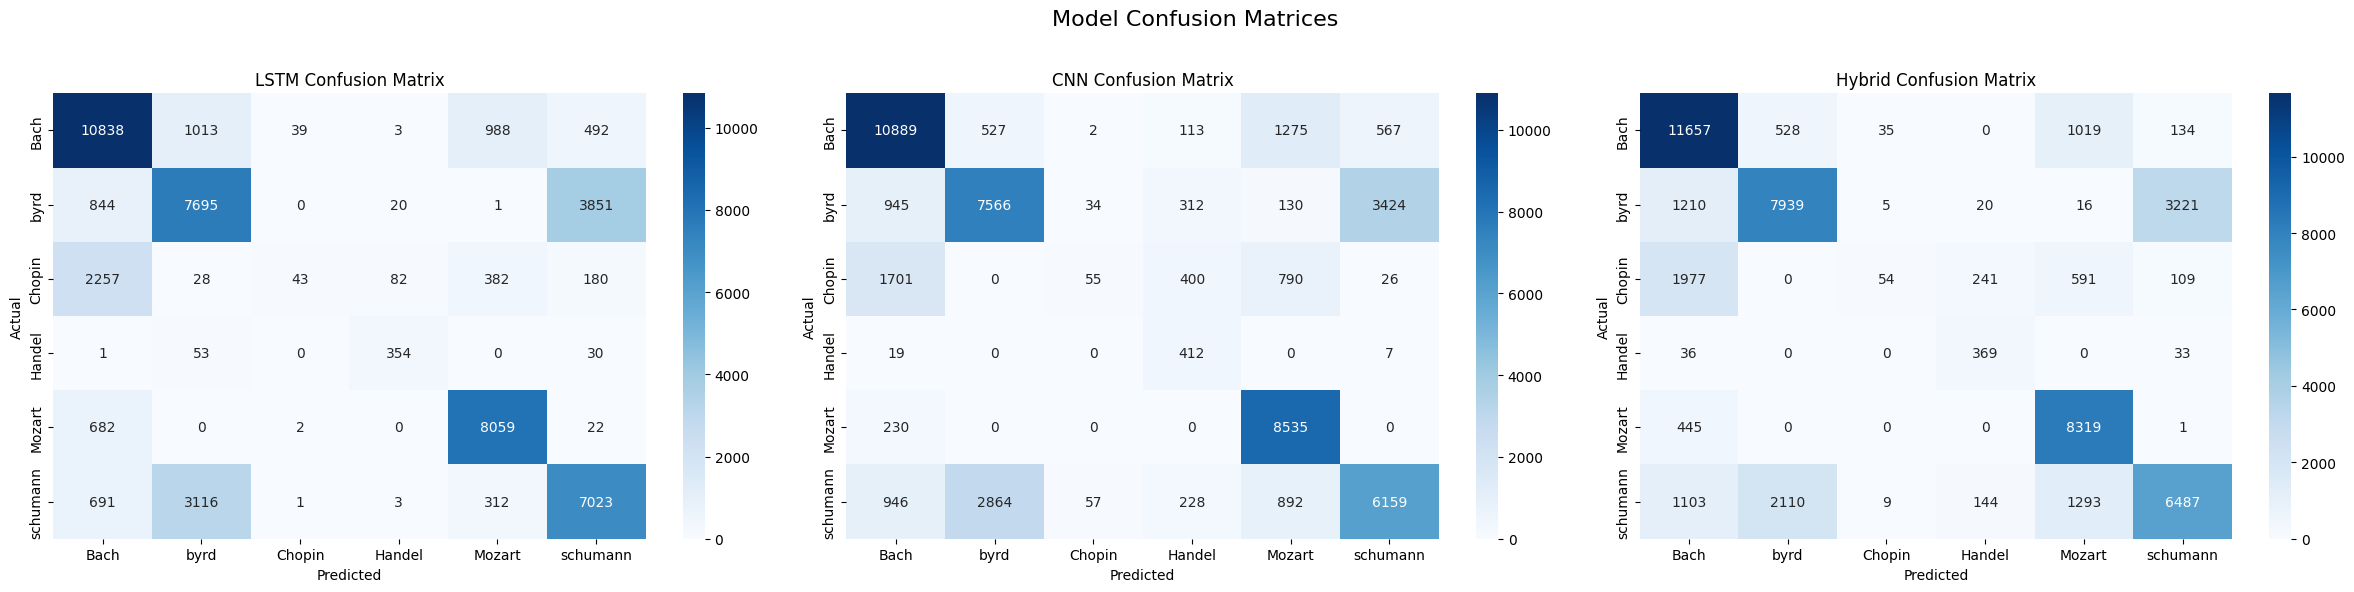

In [15]:
# 7. Visualize Results
# Training History
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Model Training History', fontsize=16)
for i, (name, info) in enumerate(models_info.items()):
    # Accuracy
    axes[0, i].plot(info['history'].history['accuracy'], label='Train Acc')
    axes[0, i].plot(info['history'].history['val_accuracy'], label='Val Acc')
    axes[0, i].set_title(f'{name} Accuracy')
    axes[0, i].legend()
    # Loss
    axes[1, i].plot(info['history'].history['loss'], label='Train Loss')
    axes[1, i].plot(info['history'].history['val_loss'], label='Val Loss')
    axes[1, i].set_title(f'{name} Loss')
    axes[1, i].legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/training_history.png')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Model Confusion Matrices', fontsize=16)
for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=composers, yticklabels=composers, ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/confusion_matrices.png')
plt.show()

In [17]:
# 8. Final Summary
print("\nFinal Model Comparison")
summary_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [res['accuracy'] for res in results.values()]
})
print(summary_df.sort_values(by='Accuracy', ascending=False))


Final Model Comparison
    Model  Accuracy
2  Hybrid  0.709195
0    LSTM  0.692638
1     CNN  0.684574
